In [1]:
!nvidia-smi

Fri May 15 04:44:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/kabNath/cuda-phy-channel-estimation.git
%cd cuda-phy-channel-estimation

Cloning into 'cuda-phy-channel-estimation'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 27 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 90.43 KiB | 6.46 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/cuda-phy-channel-estimation


In [3]:
!pip install -q -r requirements.txt
!pip install -q cupy-cuda12x

In [5]:
import cupy as cp
props = cp.cuda.runtime.getDeviceProperties(0)
print(f"CuPy version:        {cp.__version__}")
print(f"GPU model:           {props['name'].decode()}")
print(f"Compute capability:  {props['major']}.{props['minor']}")
print(f"Total VRAM:          {props['totalGlobalMem'] / 1e9:.1f} GB")

# Generate complex tensor by combining two float arrays (correct CuPy idiom)
x = (cp.random.randn(1000, 1000) + 1j * cp.random.randn(1000, 1000)).astype(cp.complex64)
y = x @ x.T
cp.cuda.Stream.null.synchronize()
print(f"Sanity GEMM OK:      shape {y.shape}, dtype {y.dtype}")

CuPy version:        14.0.1
GPU model:           Tesla T4
Compute capability:  7.5
Total VRAM:          15.6 GB
Sanity GEMM OK:      shape (1000, 1000), dtype complex64


In [6]:
!python -m benchmarks.throughput


MMSE channel estimation throughput
N=256, L=16, complex64
   Batch       CPU sym/s       GPU sym/s    Speedup
-------------------------------------------------------
      16        8.85e+04        5.05e+05       5.7x
      64        1.81e+05        1.53e+06       8.4x
     256        2.28e+05        5.76e+06      25.2x
    1024        2.26e+05        6.84e+06      30.2x
    4096        2.29e+05        8.61e+06      37.5x
   16384        1.91e+05        5.33e+06      27.9x

Figure saved to docs/throughput.png


In [7]:
import sys
sys.path.insert(0, '.')
from benchmarks.throughput import _build_W_cpu, bench_cpu, bench_gpu

W = _build_W_cpu(256, 16, 0.01)

print("\n=== READY-TO-COPY MARKDOWN TABLE ===\n")
print("| Batch size | CPU (sym/s) | GPU (sym/s) | Speedup |")
print("|-----------:|------------:|------------:|--------:|")
for B in [16, 64, 256, 1024, 4096, 16384]:
    cpu = bench_cpu(W, B, num_iters=50)
    gpu = bench_gpu(W, B, num_iters=50)
    print(f"| {B:>10,} | {cpu:>11.2e} | {gpu:>11.2e} | {gpu/cpu:>6.1f}× |")


=== READY-TO-COPY MARKDOWN TABLE ===

| Batch size | CPU (sym/s) | GPU (sym/s) | Speedup |
|-----------:|------------:|------------:|--------:|
|         16 |    9.23e+04 |    3.49e+05 |    3.8× |
|         64 |    1.60e+05 |    1.47e+06 |    9.2× |
|        256 |    2.13e+05 |    3.62e+06 |   17.0× |
|      1,024 |    1.24e+05 |    3.83e+06 |   30.8× |
|      4,096 |    1.14e+05 |    5.09e+06 |   44.7× |
|     16,384 |    2.04e+05 |    5.33e+06 |   26.1× |


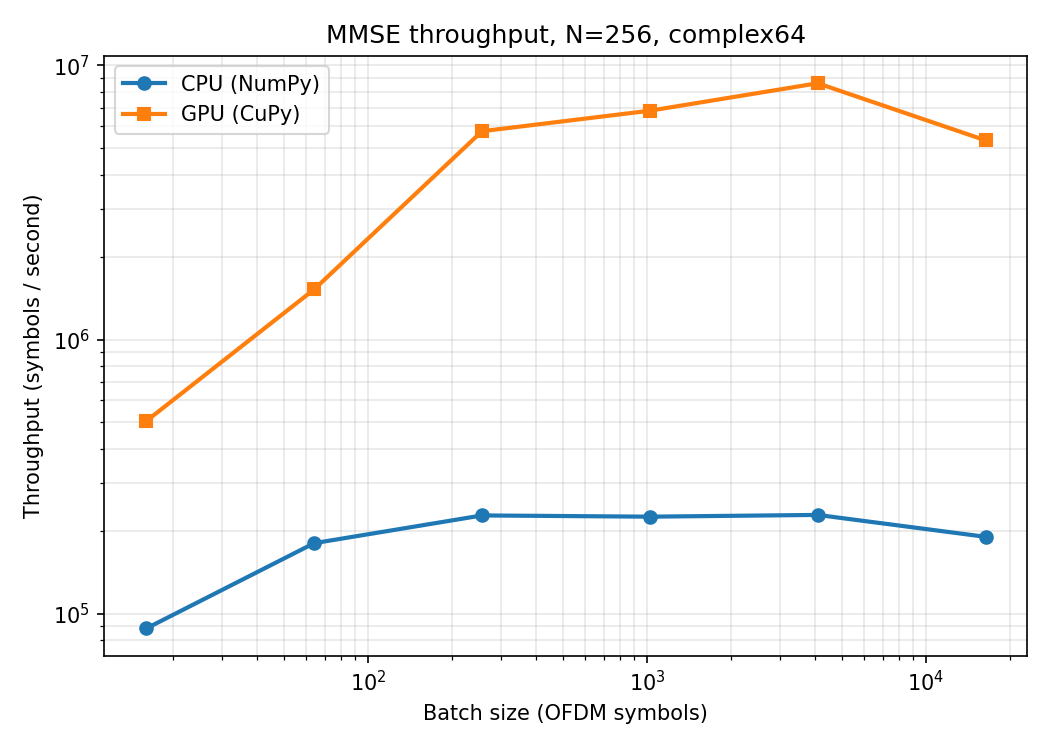

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from IPython.display import Image, display
display(Image('docs/throughput.png'))

from google.colab import files
files.download('docs/throughput.png')